# Medical Supply (Simple Linear Regression)

A company, which sells medical supplies to hospitals, clinics and doctor's offices, had considered the effectiveness of a new advertising program. Management wants to know if the advertising is related to sales. This company intends to increase the sales with an effective advertising program.

$Y$ = Sales  
$X$ = Advertising Expensidture

## 1.2 Estimation Method

In [1]:
## Read Data in R
data = read.table("R repo/Module1/Medical Supply/meddcor-4.txt", sep="", header= FALSE)
head(data)

,V1,V2,V3,V4,V5,V6
,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<int>
1,963.50,374.27,230.98,33,202.22,1
2,893.00,408.50,236.28,29,252.77,1
3,1057.25,414.31,271.57,34,293.22,1
4,1183.25,448.42,291.20,24,202.22,2
5,1419.50,517.88,282.17,32,303.33,3
6,1547.75,637.60,321.16,29,353.88,3


In [2]:
# response and predicting variable
sales = data[,1]
adv = data[,2]

# fit model
model = lm(sales~adv, data = data)
summary(model)


Call:
lm(formula = sales ~ adv, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-137.56  -92.63  -19.54   97.51  170.12 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -157.3301   145.1912  -1.084     0.29    
adv            2.7721     0.2794   9.921 8.87e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 101.4 on 23 degrees of freedom
Multiple R-squared:  0.8106,	Adjusted R-squared:  0.8024 
F-statistic: 98.43 on 1 and 23 DF,  p-value: 8.873e-10


- Estimated coefficients, $\hat{\beta}_0 = -157.3301, \hat{\beta}_1 = 2.7721$
- Residual Standard Error is the estimated standard deviation $\sigma$ (NOT variance) is 101.4
- MSE which is the estimate of the variance, $\sigma^2 = 101.4^2$
- $n-2$ = 23 degrees of freedom

**Fit a linear regression. What are the estimated regression coefficients and the estimated regression line?**
$$\text{Sales} = -157.33 + 2.77 \text{Adv Expenditure}$$
Sales and advertising are in different units  
Sales is measured in thousands  
Advertising expenditure is measured in hundreds

**Interpret the coefficients**  
Sales increases by \\$2,770 with each \\$100 additional expenditure.  
Sales increases by \\$27.70 with each \\$1 additional expenditure.

**What does the model predict as the advertising expenditure increases for an additional \\$1,000**  
The increases in sales is $1000 \times 2.77 = 2770 \times 10 = 27,700$ 

**What sales would you predict for an advertisement expenditure of $30,000?**  
The predicted sales is
$$-157.33+ 300 \times 2.77 = 673.67 \times 1000$$

**What is the estimated of the error variance?**  
Estimate $\sigma^2$ with MSE $= 101.4^2 = 10281.96$


In [13]:
max(adv)

[1] 637.6

**What could you say about the sales for an advertising expenditure of $100,000$?**  
The maximum adv is $63,760 in the dataset so we cannot "predict" the sales (response) based on this model. It is outside of the observed range because this is **extrapolation**.

## 1.3 Statistical Inference

In [4]:
summary(model)


Call:
lm(formula = sales ~ adv, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-137.56  -92.63  -19.54   97.51  170.12 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -157.3301   145.1912  -1.084     0.29    
adv            2.7721     0.2794   9.921 8.87e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 101.4 on 23 degrees of freedom
Multiple R-squared:  0.8106,	Adjusted R-squared:  0.8024 
F-statistic: 98.43 on 1 and 23 DF,  p-value: 8.873e-10


**What is the estimate of the coefficient $\beta_1$ and its variance? What is its sampling distribution?**
$\hat{\beta}_1 = 2.7721$  
Var$(\hat{\beta}_1)=\text{Std. Error}^2 = 0.2794^2$  
Sampling distribution is a $t$-distribution with 23 degress of freedom  

**What is the estimate of the coefficient $\beta_1$ and its variance?**
$\hat{\beta}_0 = -157.3301$  
Var$(\hat{\beta}_0)=\text{Std. Error}^2 = 145.1912^2$  

**Is the coefficient $\beta_1$ statistically significant? What is the p-value of the test? Interpret.**
P-value for $\beta_1$ is approximately zero, reject null hypothesis and conclude $\beta_1$ is statistically significant

**Is the coefficient $\beta_1$ statistically positive? What is the p-value of the test? Interpret**  
We have to change the alternative hypothesis to
$$H_A: \beta_1 >0$$
P-value given in R output is based on two-tailed test, so to compute p-value for one-tailed test, we need to do some calculation  
Since the null hypothesis is for less than to equal to zero, our p-value will be on the right side 

In [5]:
# t-value for two sided test for beta_1
tvalue = 9.921

# one sided t-value, pt is the probabilty of a t-distribution
# the function will always give the left tail to get the right tail
# we need to minus it from 1
1-pt(tvalue,23)

[1] 4.438411e-10

As we can see the p-value is approximately zero, we reject null hypothesis and conldue that $\beta_1$ is statistically positive

**Obtain the 99% confidence interval for $\beta_1$**

In [6]:
# calclate confidence interval
confint(model,level=0.99)

,0.5 %,99.5 %
(Intercept),-564.930546,250.27032
adv,1.987712,3.55652


We get the confidence interval for both parameters. For $\beta_1$ it is [1.988,3.557]  
Interpretation in a frequentist context means that for a 99% confidence interval, it means 1 out of 100times, the interval may miss including $\beta_1$

**What is the p-value of a hypothesis testing procedure**  
P-value measures how rejectable the null hypothesis is  
The smaller the p-value, the more rejectable the null hypothesis is for the observed data  
It is NOT the probability of rejecting null hypothesis nor is it the probability that the null hypothesis is true

## 1.4 Regression Line: Estimation & Prediction

In [3]:
summary(model)


Call:
lm(formula = sales ~ adv, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-137.56  -92.63  -19.54   97.51  170.12 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -157.3301   145.1912  -1.084     0.29    
adv            2.7721     0.2794   9.921 8.87e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 101.4 on 23 degrees of freedom
Multiple R-squared:  0.8106,	Adjusted R-squared:  0.8024 
F-statistic: 98.43 on 1 and 23 DF,  p-value: 8.873e-10


**What sales would you predict for an advertisement expenditure of $30,000**
-157.33 + 300 x 2.77 = 673.67 thousands

**What is the variance estimate of the estimated predicted sales for an advertisement expenditure of \\$30,000**  
Variance of estimated predicted sales
$$\sigma^2 \bigg(1 + \frac{1}{n}+\frac{(x^*-\bar{x})^2}{S_{xx}}\bigg)$$
$\sigma^2 = \text{MSE} = 101.4^2$  
$n = 23+2$  
$x^* = 300$  
$\bar{x} = mean(adv)$  
$S_{xx} = \frac{\text{MSE}}{var(\beta_1)}$ (from def of variance of variance of $\beta_1$)

In [4]:
mse = 101^2
n = 23 + 2
xbar = mean(adv)
var.beta1 = 0.2794^2   # standard deviation is given for all coefficient
sxx = mse/var.beta1

# pluck values into the equation
pred.var = mse*(1+(1/n)+((300-xbar)^2)/sxx)
pred.var

[1] 14201.97

**What are the lower and upper limits of predicted sales for an advertisement expenditure of \\$30,000 at 99% confidence level? How will the limits change if we lower the confidence level at 95%?**  

In [5]:
new = data.frame(adv=300)
predict.lm(model,new, interval='predict', level=0.99)
# specify the interval to predict

,fit,lwr,upr
1,674.3047,338.712,1009.897


In [7]:
predict.lm(model,new, interval='predict', level=0.95)

,fit,lwr,upr
1,674.3047,427.0146,921.5948


A 99% PI at $30,000 adv expenditure is (338.712,1009.897) while a 95% PI is (427.0146,921.5948)

**Compare the confidence intervals of the estimated regression line versus the predicted regression line. Interpret**


In [8]:
predict.lm(model,new, interval='confidence', level=0.99)

,fit,lwr,upr
1,674.3047,496.6497,851.9596


In [9]:
predict.lm(model,new, interval='confidence', level=0.95)

,fit,lwr,upr
1,674.3047,543.395,805.2143


Confidence interval (CI) at 99% (496.650,851.960) and 95% (543.400, 805.214)

The confidence intervals are narrower than the prediction intervals, this is because we have additional uncertainty due to predicting under a new setting whereas the CI are reflecting an average across all settings for that specific value. We can also see that 99% vs 95%, higher confidence will give wider interals.

## 1.6 Diagnostics and Model Evaluation Examples

**What are the assumption of linear regression?**
Linearity, Constant variance, Independence and Normality  
Note: we check uncorrelation in the residuals rather than independence

**Do the assumption hold? Provide the graphical displays needed to support the diagnostics. Interpret.**

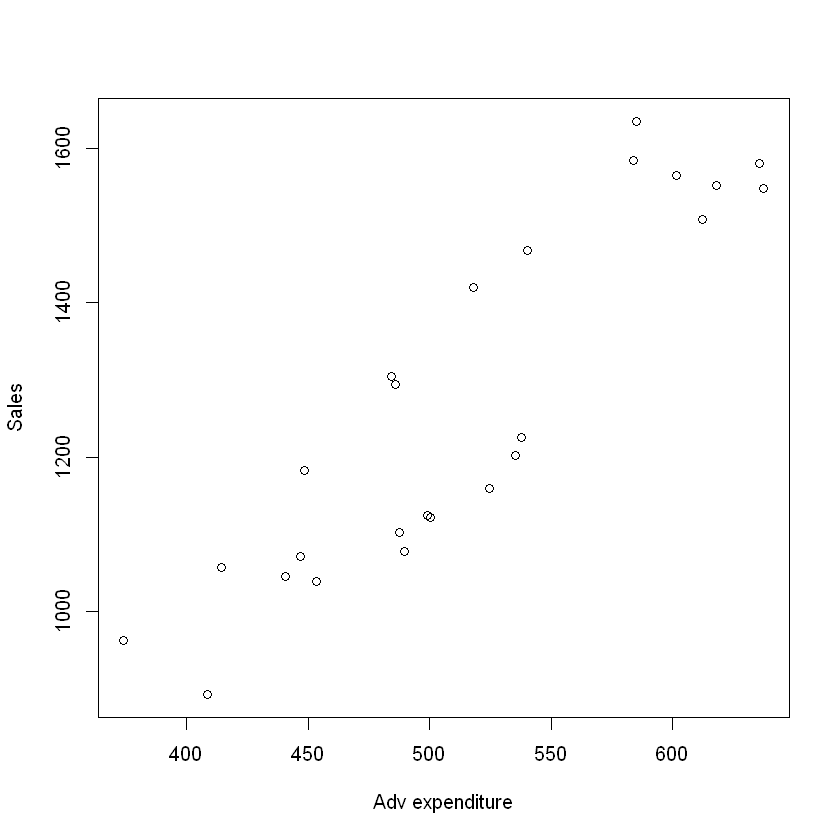

In [15]:
# Linearity: Response vs Predictor
plot(adv, sales, xlab="Adv expenditure", ylab="Sales")

We can see there is some linear relationship between $X$ and $Y$

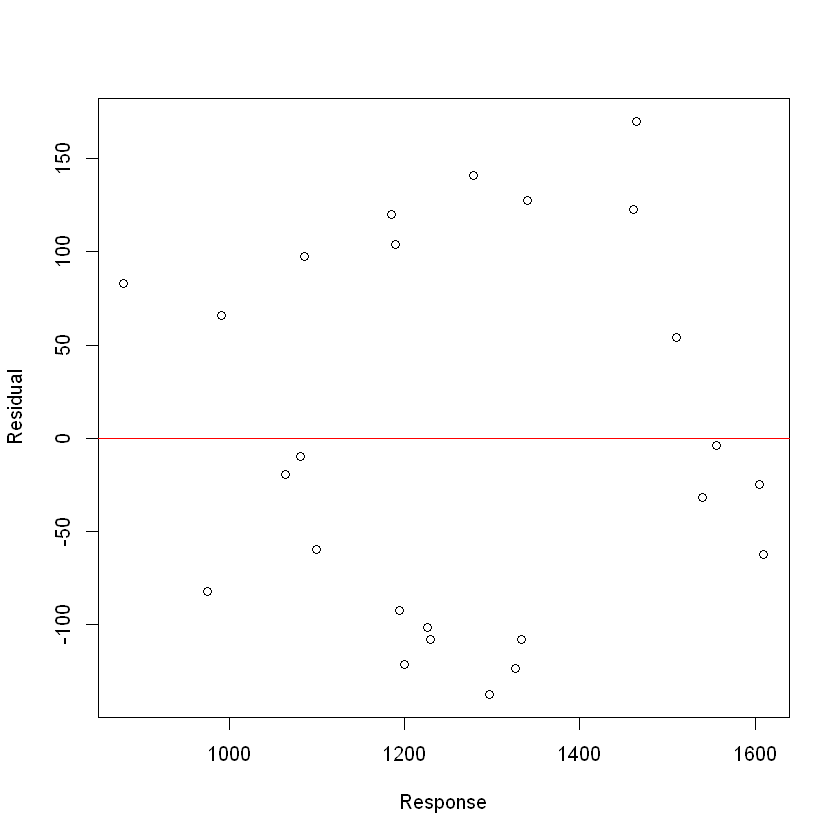

In [21]:
# constant variance & Uncorrelated errors
plot(model$fitted, model$residual ,xlab="Response", ylab="Residual")
abline(a=0,b=0, col='red')
# abline is a lone with a-intercept, b-slope

We can see the residuals are randomly scatter around zero line, constant variance and independence assumption holds

[1] 19  5

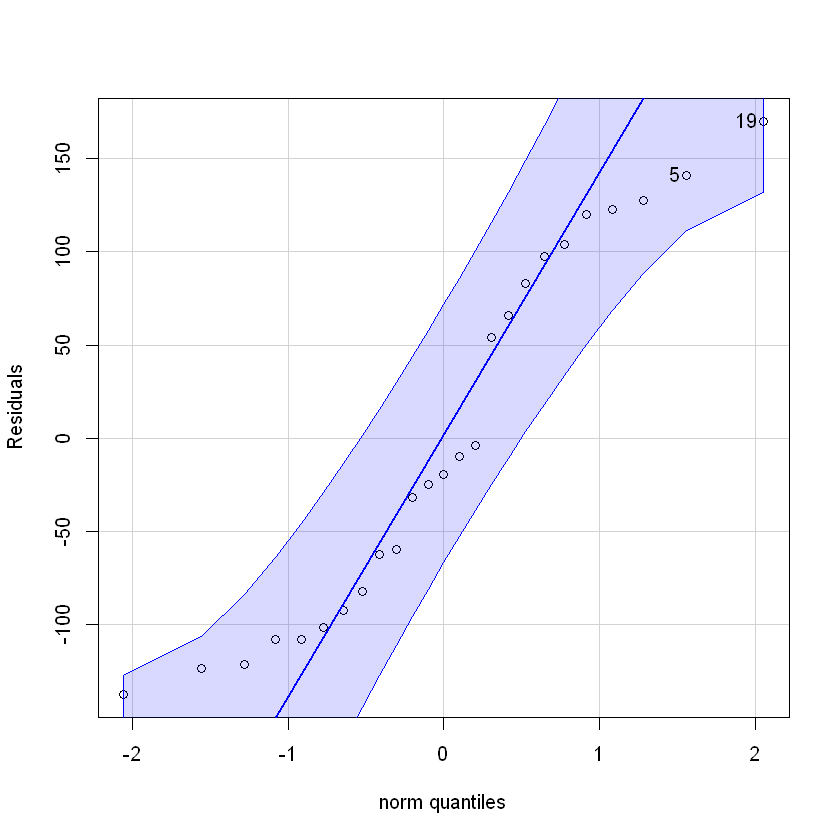

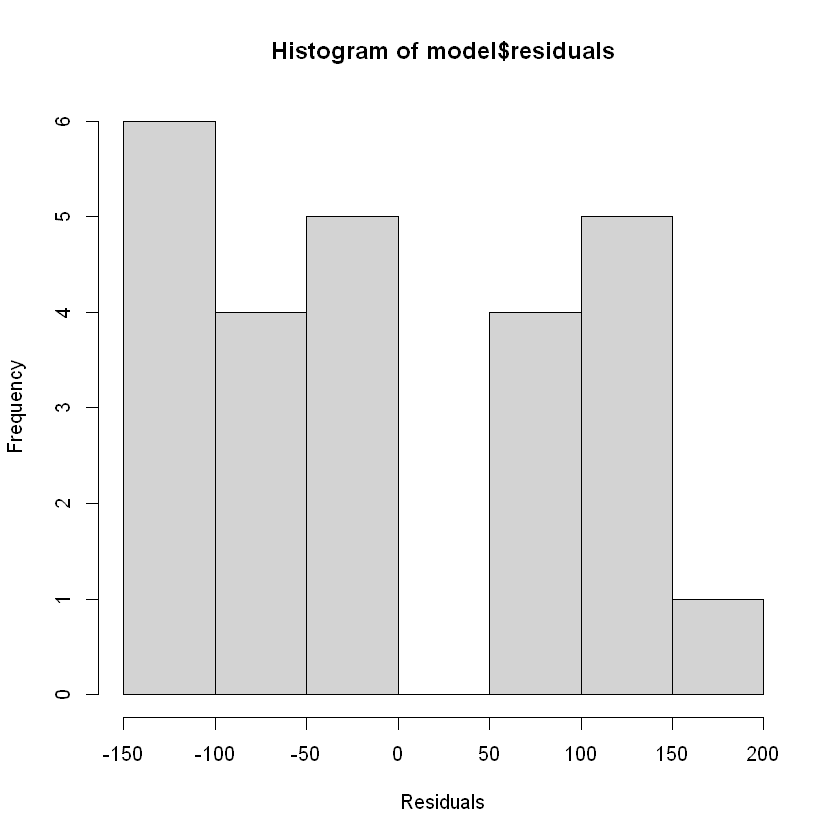

In [17]:
# normaity
library(car)
qqPlot(model$residuals, ylab="Residuals")
hist(model$residuals, xlab="Residuals")

- Some departure from normality especially in the tail of the quantile normal plot, which could be an indication that the distribution of the residuals is somewhat skewed.
- However the histogram shape does not look like heavy tailed but having a gap in the distribution. The shape is also not normal distribution.
- rather small number of observations hence the two plots does not provide reliable assessments
- only be concerned about normality when very strong departures from normality is shown
- overall, based on those plots, the assumptions appear to hold
- don’t see any unusual data points that could indicate that we have outliers

**Evaluation of normality assumption using residual instead of response variable $y$**
Response may be multi-modal (happens when a *qualitative* predictor predicts the response well)
Hence, we have to use residual insead of response to check for normality.

**How much variability in sales is explained by the advertising expenditure? Is the adjust R-squared different?**


In [23]:
summary(model)$r.squared

[1] 0.8105919

In [24]:
summary(model)$adj.r.squared

[1] 0.8023567

Around 81% of the variability in sales is explained by the advertising expenditure  
Adj-$R^2$ is slightly lower than $R^2$ but we only use adj-$R^2$ in model comparison